In [1]:
from src.sampling.main import stratified_spatial_kfold_dual #Dont know why but this has to be initialised first else kernel crashes

import torch
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datetime import datetime
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader as GeometricDataLoader
from torch_geometric.transforms import ToUndirected

from src.performance_logger import PerformanceLogger
from models.gnn import GNNInductiveHetero
from src.utils import read_config
from src.raingauge.utils import (
  load_raingauge_dataset
)
from src.radar.utils import load_radar_dataset, load_processed_dataset
from src.cml.utils import load_cml_dataset
from training.logic_hetero import train_epoch, validate, test_model
from src.graph.radargraph import RadarGraph
from src.graph.gaugegraphnew import GaugeGraphNew, HeterogeneousWeatherGraphDatasetInductive
from src.graph.cmlgraph import CMLGraph

%load_ext autoreload
%autoreload 2

/opt/miniconda3/envs/fyp/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config = read_config('config.yaml')
batch_size = config['training_params']['batch_size']
fold_count = 1

In [3]:
experiment_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_new"
os.makedirs(f"experiments/{experiment_name}", exist_ok=True)
perf = PerformanceLogger(f"experiments/{experiment_name}/training_log.jsonl")

In [4]:
uptime_threshold = config['filters']['uptime_threshold']
start_year = config['dataset_parameters']['start_year']
end_year = config['dataset_parameters']['end_year']
raingauge_df, raingauge_station_mappings_df = load_raingauge_dataset(start = start_year, end = end_year, uptime_threshold=uptime_threshold)

Loading raingauge data from 2024 to 2025
Loading raingauge_dataset from database/raingauge_nea_data/2024/weather_station_data_2024.csv
Loading raingauge_dataset from database/raingauge_nea_data/2025/weather_station_data_2025.csv
Loading complete
Dataframe shape: (209691, 70)
Filtering raingauge_uptime. Threshold = 0.9
Getting raingauge coordinate mappings
Mapping df shape: (51, 4)


In [5]:
radar_df = load_processed_dataset('database/processed_radar_dataset.pkl')

In [6]:
radar_df.sort_values(by='timestamp')

,timestamp,data,bounds,crs,transform
0,2024-06-01 08:00:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.59855210085554, 1.193961509939045, 104.09...","(proj, datum, no_defs)","(0.009948089062528141, 0.0, 103.59855210085554..."
1,2024-06-01 08:15:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.59855210085554, 1.193961509939045, 104.09...","(proj, datum, no_defs)","(0.009948089062528141, 0.0, 103.59855210085554..."
2,2024-06-01 08:30:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.59855210085554, 1.193961509939045, 104.09...","(proj, datum, no_defs)","(0.009948089062528141, 0.0, 103.59855210085554..."
3,2024-06-01 08:45:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.59855210085554, 1.193961509939045, 104.09...","(proj, datum, no_defs)","(0.009948089062528141, 0.0, 103.59855210085554..."
4,2024-06-01 09:00:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.59855210085554, 1.193961509939045, 104.09...","(proj, datum, no_defs)","(0.009948089062528141, 0.0, 103.59855210085554..."
...,...,...,...,...,...
31498,2025-05-01 06:45:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.60000000000001, 1.19, 104.10000000000001,...","(proj, datum, no_defs)","(0.01, 0.0, 103.60000000000001, 0.0, -0.009999..."
31499,2025-05-01 07:00:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.60000000000001, 1.19, 104.10000000000001,...","(proj, datum, no_defs)","(0.01, 0.0, 103.60000000000001, 0.0, -0.009999..."
31500,2025-05-01 07:15:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.60000000000001, 1.19, 104.10000000000001,...","(proj, datum, no_defs)","(0.01, 0.0, 103.60000000000001, 0.0, -0.009999..."
31501,2025-05-01 07:30:00,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","(103.60000000000001, 1.19, 104.10000000000001,...","(proj, datum, no_defs)","(0.01, 0.0, 103.60000000000001, 0.0, -0.009999..."


In [7]:
cml_df, cml_coordinates_df = load_cml_dataset('CML_data_Feb2025-April2025.nc')

In [8]:
split_info = stratified_spatial_kfold_dual(
    raingauge_station_mappings_df, seed=123, plot=False, n_splits = fold_count 
)

SPATIAL K-FOLD STRATIFIED SAMPLING (Fixed)
Total stations: 51
Clusters: 8
Folds: 1
Random seed: 123
--------------------------------------------------------------------------------
Cluster 0: 2 stations → 1 test assignments, 1 always-train
Cluster 1: 7 stations → 1 test assignments, 6 always-train
Cluster 2: 6 stations → 1 test assignments, 5 always-train
Cluster 3: 13 stations → 1 test assignments, 12 always-train
Cluster 4: 7 stations → 1 test assignments, 6 always-train
Cluster 5: 7 stations → 1 test assignments, 6 always-train
Cluster 6: 4 stations → 1 test assignments, 3 always-train
Cluster 7: 5 stations → 1 test assignments, 4 always-train

Creating Fold 1/1
Test stations: 8 (should be ~8)
Train pool: 43
Fold 1 summary:
  Statistical train: 43 (84.3%)
  Test: 8 (15.7%)
  ML train: 35 (68.6%)
  ML validation: 8 (15.7%)

VERIFICATION
Total unique test stations across all folds: 8
Expected: 8
✓ K-Fold validation complete!


In [9]:
#MERGE THE RADAR AND GAUGE DATA
cml_cols = cml_df.columns
raingauge_cols = raingauge_df.columns
raingauge_cols = raingauge_cols
radar_cols = radar_df.columns
merged_df = radar_df.merge(raingauge_df, how='inner', on=['timestamp']).merge(cml_df, how='inner', on=['timestamp'])


In [10]:
cml_df = merged_df[cml_cols]
raingauge_df = merged_df[raingauge_cols]
radar_df = merged_df[radar_cols]
raingauge_df = pd.concat([merged_df['timestamp'], merged_df[raingauge_cols]], axis=1).drop_duplicates().reset_index()
cml_df = cml_df.drop_duplicates()
radar_df = radar_df.drop_duplicates(subset=['timestamp'], keep='first')

In [11]:
#Drop the timestamp column
raingauge_df = raingauge_df.drop(columns=['timestamp'])
rainfall_values = torch.tensor(raingauge_df.values.T)
rainfall_validity = torch.tensor(raingauge_df.notna().astype(int).values.T)
raingauge_features = torch.stack([rainfall_values, rainfall_validity], dim = 2)
raingauge_features.shape

torch.Size([52, 8419, 2])

In [12]:
cml_coordinates_df

,index,site_a_latitude,site_a_longitude,site_b_latitude,site_b_longitude,station,link_id,length,frequency,polarization
0,0,1.374917,103.835611,1.375944,103.839889,Station A,AMK_1012_1655_59-ODU_25-ODU,0.49,23.0,V
1,8636,1.374917,103.835611,1.375944,103.839889,Station B,AMK_1012_1655_59-ODU_25-ODU,0.49,23.0,V
2,17272,1.371889,103.870361,1.366972,103.859722,Station A,AMK_1064_AMK271B_23-ODU_23-ODU,1.30,18.0,HV
3,25908,1.371889,103.870361,1.366972,103.859722,Station B,AMK_1064_AMK271B_23-ODU_23-ODU,1.30,18.0,HV
4,34544,1.371889,103.870361,1.366972,103.859722,Station A,AMK_1064_AMK271B_24-ODU_24-ODU,1.30,18.0,HV
...,...,...,...,...,...,...,...,...,...,...
823,7107428,1.347389,103.854139,1.350167,103.852361,Station B,YIS_5497_5180_62-ODU_62-ODU,0.73,23.0,HV
824,7116064,1.347389,103.854139,1.350167,103.852361,Station A,YIS_5497_5180_63-ODU_63-ODU,0.73,23.0,HV
825,7124700,1.347389,103.854139,1.350167,103.852361,Station B,YIS_5497_5180_63-ODU_63-ODU,0.73,23.0,HV
826,7133336,1.347389,103.854139,1.350167,103.852361,Station A,YIS_5497_5180_64-ODU_64-ODU,0.73,23.0,HV


In [13]:
gauge_graph_arr = []
for i in range(fold_count):
  gauge_graph = GaugeGraphNew(raingauge_df, raingauge_station_mappings_df, split_info = split_info[i], knn=5)
  radar_graph = RadarGraph(radar_df)
  cml_graph = CMLGraph(cml_df, cml_coordinates_df)
  radar_heterodata = radar_graph.get_radar_heterodata()
  cml_heterodata = cml_graph.get_heterodata()
  gauge_graph.add_heterodata(heterodata_layer=radar_heterodata, coords = radar_graph.grid_coords, layer_name='radar', knn=10)
  gauge_graph.add_heterodata(heterodata_layer=cml_heterodata, coords = cml_coordinates_df, layer_name='cml', knn = 10)
  gauge_graph_arr.append(gauge_graph)
  

/opt/miniconda3/envs/fyp/lib/python3.13/site-packages/shapely/measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)
/opt/miniconda3/envs/fyp/lib/python3.13/site-packages/shapely/measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)
/opt/miniconda3/envs/fyp/lib/python3.13/site-packages/shapely/measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


In [14]:
gauge_graph_arr[0].get_train_heterodata()

HeteroData(
  raingauge={
    x=[35, 8419, 6],
    y=[35, 8419, 1],
    mask=[0],
    num_nodes=35,
  },
  radar={ x=[1550, 8419, 1] },
  cml={ x=[828, 8419, 13] },
  (raingauge, connects, raingauge)={
    edge_index=[2, 228],
    edge_attr=[228],
  },
  (radar, connect, radar)={
    edge_index=[2, 11918],
    edge_attr=[11918],
  },
  (radar, connects, raingauge)={
    edge_index=[2, 350],
    edge_attr=[350],
  },
  (cml, connect, cml)={
    edge_index=[2, 828],
    edge_attr=[828],
  },
  (cml, connects, raingauge)={
    edge_index=[2, 700],
    edge_attr=[700],
  }
)

6
7
8


/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraphnew.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.test_gauges = split_info['ml']['test']


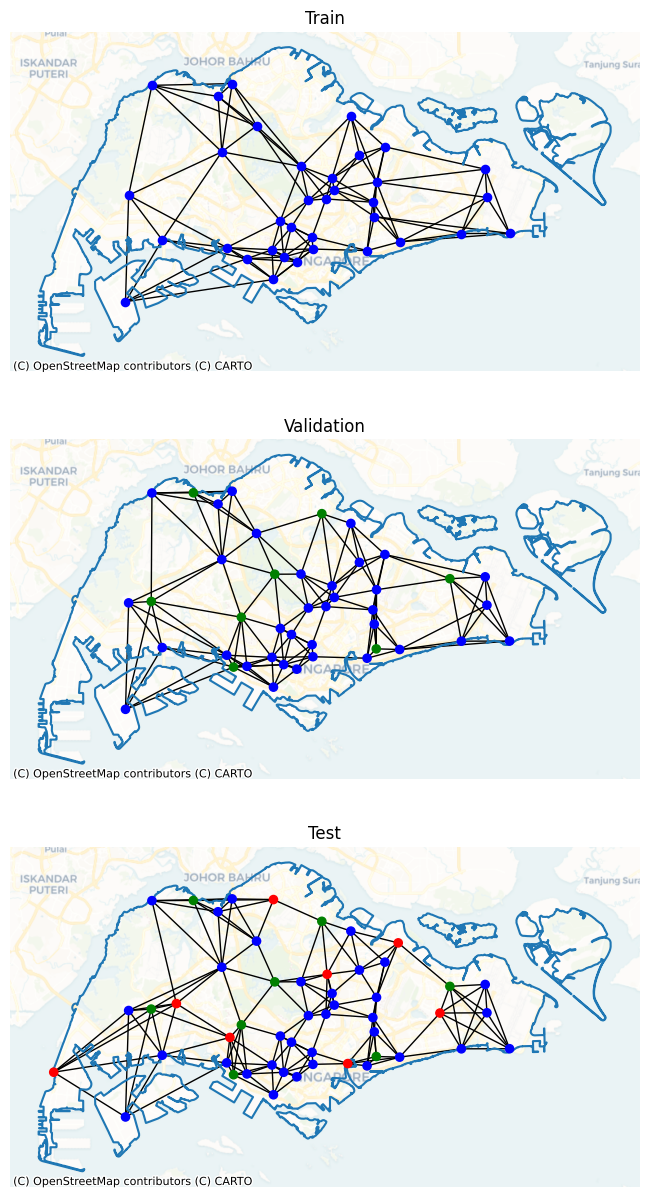

In [33]:
gauge_graph_arr[0].visualise_graph_split()

In [16]:
gauge_graph_arr[0].get_train_heterodata()['cml'].x.shape[2]

13

In [17]:
from torch_geometric.transforms import AddLaplacianEigenvectorPE

lpe_transform = AddLaplacianEigenvectorPE(k=4, attr_name = 'laplacian_pe')
temp_graph = gauge_graph_arr[0].get_train_heterodata()

temp_graph = lpe_transform(temp_graph)

AttributeError: 'HeteroData' has no attribute 'edge_index'

In [ ]:
hidden_channels = 8
out_channels = 1
num_layers = 8
model_arr = []
for i in range(fold_count):
  model_arr.append(
    GNNInductiveHetero(
      in_channels_dict = {
        "raingauge": 2,
        "radar": 1, 
        "cml": -1
      },
      hidden_channels = hidden_channels,
      out_channels=out_channels, 
      num_layers = num_layers,
      edge_types = gauge_graph_arr[i].fused_test_heterodata.edge_types
    ).to(device=device)
  )

In [ ]:
train_loader_arr = []
val_loader_arr = []
test_loader_arr = []
batch_size = 1
for i in range(fold_count):
    train_loader = GeometricDataLoader(
    HeterogeneousWeatherGraphDatasetInductive(gauge_graph_arr[i].get_train_heterodata()), #Need to convert to timestep wise data
    batch_size=batch_size,
    shuffle= False,
    )

    val_loader = GeometricDataLoader(
    HeterogeneousWeatherGraphDatasetInductive(gauge_graph_arr[i].get_validation_heterodata()),
    batch_size=batch_size,
    shuffle=False,
    )

    test_loader = GeometricDataLoader(
    HeterogeneousWeatherGraphDatasetInductive(gauge_graph_arr[i].get_test_heterodata()),
    batch_size = batch_size, 
    shuffle = False
    )

    train_loader_arr.append(train_loader)
    val_loader_arr.append(val_loader)
    test_loader_arr.append(test_loader)

In [ ]:
next(iter(test_loader_arr[0]))

In [ ]:
def train_fold(model, train_loader, val_loader, fold, device="cpu"):
    # CHECK 1: Print initial weights
    print("Training")
    print(f"Device type: {device}")
    first_param = next(model.parameters())
    print(f"Initial weight sample: {first_param.data.flatten()[:5]}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    training_loss_arr = []
    validation_loss_arr = []
    early = 0
    mini = 1000
    stopping_condition = 5
    epochs = 0
    total_epochs = 10
    print(f"-----FOLD: {fold}-----")
    training_start = time.time()
    for i in range(total_epochs):
        epoch_start = time.time()
        print(f"-----EPOCH: {i + 1}-----")

        # CHECK 2: Print weight before training
        weight_before = first_param.data.clone()

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            device,
            verbose=False,
            random_noise_masking=False,
        )
        print(train_loss)

        # CHECK 3: Print weight after training
        weight_after = first_param.data
        weight_change = (weight_after - weight_before).abs().mean().item()
        print(f"Weight change: {weight_change:.20f}")

        validation_loss = validate(model, val_loader, device)
        training_loss_arr.append(train_loss)
        validation_loss_arr.append(validation_loss)
        perf.log_epoch(i, train_loss, validation_loss)
        if mini >= validation_loss:
            mini = validation_loss
            early = 0
        else:
            early += 1
        epochs += 1
        if early >= stopping_condition:
            print("Early stop loss")
            break

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Loss: {validation_loss:.4f}")

        # CHECK 4: Print gradient norms
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm**0.5
        print(f"Gradient norm: {total_norm:.6f}")
        epoch_end = time.time()
        print(f"epoch {i} took {epoch_end - epoch_start}")
    training_end = time.time()
    total_time = training_end - training_start
    perf.finalise(total_time)

    print(f"Training took {total_time} seconds over {epochs} epochs")
    plt.plot(training_loss_arr, label="training_loss", color="blue")
    plt.plot(validation_loss_arr, label="validation_loss", color="red")
    plt.legend()
    plt.savefig(f"experiments/{experiment_name}/train_loss_plot_{fold}.png", dpi=300)
    plt.close()

    torch.save(
        model.state_dict(), f"experiments/{experiment_name}/weather_gnn_best_{fold}.pth"
    )
    print("✅ model weights saved to weather_gnn_best.pth")

In [ ]:
next(iter(train_loader_arr[0]))['raingauge','connects','cml']

In [ ]:
for i in range(fold_count):
  train_fold(model_arr[i], train_loader=train_loader_arr[i], val_loader=val_loader_arr[i], fold = i)
  RMSE = test_model(model_arr[i], raingauge_station_mappings_df, test_loader_arr[i], device, fold = i, experiment_name=experiment_name)

In [ ]:
RMSE = test_model(model_arr[0], raingauge_station_mappings_df, test_loader, device, fold = 0, experiment_name=experiment_name)